# n_TOF $^{239}$Pu(n,f) cs shape data preparation for GMA (Data release: LA-UR-25-32229)

## Comments:
- This uses averaged Pu9 n_TOF shape data provided by Naohiko Otsuka (meant for EXFOR) which is by the experimenters. The Standards adopt them only above 150 keV and use them in the GMA file as ratios to 235U. DN created the ratios by dividing 235U(n,f) cs from 2018 Standard.
- Adrian Sanchez-Caballero wrote on 2/4/2026 that they used the 2018 U-235 Neutron Data Standard for obtaining an evaluated neutron flux. See://doi.org/10.1140/epja/s10050-025-01727-x 

In [3]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid, interp
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [6]:
import Class_nfcs as Cnf
reload(Cnf)

<module 'Class_nfcs' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs.py'>

Text(0, 0.5, 'Relative Uncertainty (%)')

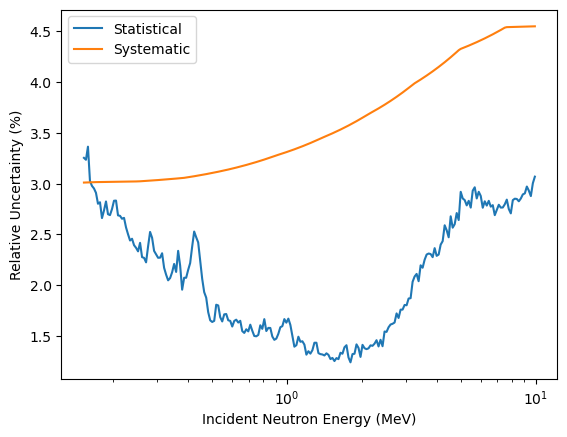

In [7]:
forStandards = True

# Data in here are all provided by N. Otsuka and will be in EXFOR.
datafile = homedir+'SanchezCaballeroAbove150keV.txt'
alldata  = loadtxt(datafile,comments="#")

Einclow  = alldata[:,0] * 1.0e-6 # MeV
Einchigh = alldata[:,1] * 1.0e-6 # MeV
edgesE      = zeros(len(Einclow) + 1,dtype=float)
edgesE[:-1] = Einclow
edgesE[-1]  = Einchigh[-1]
# For energy resolution.

Einc = Einclow*0.5 + Einchigh*0.5
Data = alldata[:,2] # Pu-239(n,f), the data are 
# given relative to the 239Pu(n,f) cross section integral 
# in the 9–20 eV assuming a value of 1059(6) eV · b.
# The authors clearly state that these data should be treated as shape.

Statunc = alldata[:,3]*100.0/Data # The statistical uncertainties are given.
# From authors: Statistical uncertainties include only those due to counting statistics.


Systunc = alldata[:,4]*100.0/Data # The systematic uncertainties are given.
# It is the uncertainty in the shape of the neutron flux. It certainly does NOT contain the 
# normalization unc. for normalizing to the integral or the fission
# detector uncertainty. These are given seaparately.
# From authors, the systematic unc. is only due to the energy unc. of the neutron flux. 
# This is a combination of statistical and systematic uncertainty on the neutron flux.
# Systematics dominate.
# It is written in Ref. Eur. Phys. J. A (2025) 61:277, https://doi.org/10.1140/epja/s10050-025-01727-x:
# ``The systematic uncertainty for each of the measurements has been calculated by means of error propagation, 
# considering the uncertainty of the different corrections applied during the data analysis, as
# well as the uncertainties related to the use of evaluated cross
# sections and MC simulations." 
# If I want to treat the data as in ratio to U-235, I need to reduce the neutron flux uncertainty by the Standard.

plt.semilogx(Einc,Statunc)
plt.semilogx(Einc,Systunc)
plt.legend(['Statistical','Systematic'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [8]:
# The Standards group wants the data divided through the $^{235}$U(n,f) Standard from 2017 because that is what was
# used for the neutron flux.
# That entails reducing the neutron flux uncertainties by the Standards uncertainties which are considered.

if forStandards:
    # reading data --------------------------
    datafile = homedir+'std17-092_U_235.txt'
    alldata  = loadtxt(datafile,comments="#")
    
    EincU235  = alldata[:,0] # MeV
    csU235    = alldata[:,1] # b
    csuncU235 = alldata[:,2] # cs unc. 
    # ---------------------------------------

    # interpolation to the right grid -------
    csU235low = interp(Einclow,EincU235,csU235)
    csU235high= interp(Einchigh,EincU235,csU235)
    # ---------------------------------------

    # getting ratio data --------------------
    ratio = Data/(0.5*(csU235low+csU235high))
    # ---------------------------------------

    # reducing uncertainty data -------------
    csuncU235low = interp(Einclow,EincU235,csuncU235)
    csuncU235high= interp(Einchigh,EincU235,csuncU235)
    stdunc       = 0.5*(csuncU235low+csuncU235high)    
    Fluxunc      = sqrt(Systunc*Systunc-stdunc*stdunc)
    Systunc      = Fluxunc
    # ---------------------------------------

In [9]:
# Uncertainties defined in their paper.
deteffunc = 0.5 # This detector efficiency unc. is ignore per the email with authors because 
# it is a fully correlated component and their data is shape data.

TOFlength = 185.59 # m
TOFlength_unc = 0.01 # m

# stopping power and multiple scatterig minimized by thin sample.
# From authors, the systematic unc. is only due to the energy unc. of the neutron flux. 
neutronflux_unc = Systunc

In [10]:
features = {"Author": ["n_TOF collaboration","A. Sanchez-Caballero", "D. Cano-Ott","E. Mendoza","et al."],
"Year": "2025",
'Absolute':'n',\
"Facility": ['SYNCY', 'SPALL', '2ZZZCER'],
"Institute": ["2ZZZCER","2SPNPCM"],
"Isotope": "Pu-239",
"Quantity": "cs", 'reaction': 'n,f',\
"MeasurementType": "Indirect ratio shape",
"ConcernEXFOR": "N/A",
"ConcernPARADIGM": ["Angular distribution","Forward boots","Multiple scattering","Attentuation"],
"ConcernAIACHNE_text": ["No corrections were applied for angular distribution of FF, forward-boost of FF, multiple scattering and attenuation of incoming neutrons in detector and surrounding materials. No thermal background correction was mentioned but could be small."],
"BackgroundCorrected": "partial",
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "n",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "N/A",
"MultipleScatteringSampleBackingCorrected": "n",
"MultipleScatteringSurroundingCorrected": "n",
"AttenuationSampleBackingCorrected": "n",
"AttenuationSurroundingCorrected": "n",
"FissionDetectionEfficiencyCorrected": "y",
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "N/A",
"SignalPulsePileupCorrected": "N/A",
"DeadtimeCorrected": "N/A",
"AngularDistributionFissionFragmentsCorrected": "n",
"ForwardBoostCorrected": "n",
"ImpuritiesCorrected": "y",
"CorrelatedData": "23458.006",
"EXFORnumber": "None",
"Accepted": "y",
"MissingCorrections": ["ThermalBackground","MultipleScatteringSampleBackingCorrected",\
                       "MultipleScatteringSurroundingCorrected","AttenuationSampleBackingCorrected",\
                      "AttenuationSurroundingCorrected","AngularDistributionFissionFragmentsCorrected",\
                      "ForwardBoostCorrected"],
"FissionDetector": {
"Type": "IOCH",
"ParticleDetected": "FF",
"Efficiency": 89.4,'Efficiency_unit':'%',
"EfficiencyMethod": ["unknown"],
"FFAbsorptionAngularDistributionMethod": "N/A",
"AngularAcceptaneofFF": "unknown",
"Gas": {"Type": ["Ar","CF4"], "Purity": ["90.0","10.0"], "Pressure": "1","Pressure_unit":"atm"},
"Size": {"geometry": "cylindrical volumes; dimensions unknown"},
"NoPhotomultipliers": "N/A",
"Weight": "unknown",
"StructuralMaterial": "unknown",
"ReferenceDetector": "N/A"},
"NeutronDetector": {
"Type": ["6Li(n,t)",'10B(n,alpha)','235U(n,f)'],
"Number": ["unknown","unknown","unknown"],
"ParticleDetected": ["t","alpha","FF"],
"Efficiency": ["unknown","unknown","unknown"],
"ResponseDeterminationMethod": ["unknown","unknown","unknown"],
"EfficiencyDeterminationMethod": ["unknown","unknown","unknown"],
"Angle": ["unknown","unknown","unknown"], 
"trsl": {"Value": ["unknown","unknown","unknown"], "Unit": ["ns","ns","ns"], "Measure": "N/A"},
"t0Determination": ["unknown","unknown","unknown"],
"Gas": {"Type": ["unknown","unknown","unknown"], "Purity": ["unknown","unknown","unknown"], "Pressure": ["unknown","unknown","unknown"]},
"Size": {"geometry": ["unknown","unknown","unknown"]},
"NoPhotomultipliers": ["unknown","unknown","unknown"],
"Photomultipliers": ["unknown","unknown","unknown"],
"Weight": ["unknown","unknown","unknown"],
"StructuralMaterial": ["unknown","unknown","unknown"],
"ReferenceDetector": "N/A",
"ReferenceReaction": ["6Li(n,t)",'10B(n,alpha)','235U(n,f)']
},
"Shielding": {"Material": "unknown", "Size": "unknown", "DistanceFromNeutronDetector": "N/A", "Purpose": "unknown"},
"Sample": {"Number":10,
"Activity": 2.0,
"Activity_unit": "Mbq/mg",
"Reused": "no",
"Form": "plate",
"Mass": [1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.1], "Mass_unit":'mg',
"Diameter": [2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0], "Diameter_unit":'cm',
"Thickness": [300,300,300,300,300,300,300,300,300,40], "Thickness_unit":'mug/cm2',
"Homogenity": "within 5%",
"Contaminants": {'239Pu':99.90259,'240Pu':0.05818,'241Pu':0.02501,'242Pu':0.01288},
"BackingMaterial": "Al",
"BackingDiameter": "unknown",
"BackingThickness": 10.0,'BackingThickness_Unit':'mum',
"DecayDeterminationMethod": "N/A",
"Configuration": "Stack",
"Fabrication": "molecular plated",
"ImpurityDetermination": " thermal ionization mass spectrometry"
},
"ShadowBar": {"Used": "unknown", "Material": "unknown", "Size": "unknown", "Size_unit": "mm", "Material of structure holding it": "unknown"},
"OutgoingEnergyDetermination": "TOF",
"IndividualChannelWidthDetermination": "unknown",
"AverageChannelWidthDetermination": "Fission peak",
"BackgroundMethods": {
"General": "corrections applied as listed",
"Wraparound": "N/A",
"alpha": ["PSD","design"],
"Gamma": ["PSD","measured (with Total Absorption Calorimeter)"],
"RandomCoincidence": "N/A"
},
"MultipleScatteringMethods": {"InSample": "N/A", "Surrounding": ["N/A"]},
"AttenuationMethods": {"InSample": "N/A", "Surrounding": ["N/A"]},
"DeadtimeDeterminationMethod": "N/A",
'EnergyDetermination':'TOF',
'NeutronBeam':{'Facility':['SYNCY', 'SPALL', '2ZZZCER'],'PulseWidth':7,'PulseWidthUnit':'ns',
               'NeutronProducingReaction':'p,Pb','Target':'Pb',
'EnergySpread':'0.03% at 1 eV to 0.5% at 1 MeV',
'Monitor':['6Li(n,t)','10B(n,alpha)','235U(n,f)','197Au(n,gamma) '],
'Diameter':'unknown','Diameter_unit':'N/A','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',
"TOFLength": {"Value": 185.59 , "Unit": "m", "Unc": 0.01,"Unc_Unit":'m'},\
'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
't0Determination':'239Pu fission resonances'}          
}



### Comments:
- Given their write-up, I treat the data as shape ratios. At the Standards meeting in January 2026, we decided to take only the data above 150 keV and treat them as ratios to 235U because the flux was measured in the energy range as ratios to 235U(n,f) cross sections and assuming the 2018 Standard for the 235U(n,f) cross sections.
- I assume the detector efficiency uncertainty of 0.5% drops out because it is a normalization uncertainty that would have been taken care of by the normalization, but as we take the data as shape, it does not apply.
- The angular distribution and forward-boost uncertainty is energy-dependent and as such does apply to shape data. Given their answer, I add in an angular distribution and forward-boost uncertainty that is 0% up to 3 MeV and then linearly rises to 2% up to 10 MeV. I assume that the effect of sample thickness is negligible given their write-up and add no uncertainty.
- No extra uncertainty is added on the neutron flux because it is their systematic uncertainty. The neutron flux uncertainty includes the Standard uncertainty. So, I need to reduce it for that.
- I assume background uncertainties for now to be 0% per the guidance of n_TOF authors. However, note that we are just investigating with fissionTPC folks the likelihood of thermal background. Could a similar thermal background apply to them? Or is that highly unlikely because they have a much longer flight path >100 m versus 100 cm for fissionTPC? Roberto Capote wrote that they use the calorimeter and shield their detector with cadmium or boron, not recall which one, so no thermal background.
- I assume they don’t have a wrap-around background? (lowest-energy neutrons from the preceding pulse are overlapping with the fastest neutrons from the current pulse.) Roberto Capote confirmed that they have no wrap-around background.
- They only address in their answer neutron attenuation and multiple scattering in the sample but not in the surrounding. This is especially relevant as this is not a clean-ratio measurement, where U-235 is in the same chamber, but rather in different detectors where they might see a beam more distorted by neutron scattering. The key question is how far away are the neutron monitor measurements? Is there a lot of material? Right now, I would add my typical template values of 0.2-2%.
- I believe them on deadtime uncertainty being 0.
- I add a negligibly small impurity uncertainty of 0.01% (this corresponds to their sample purity of 99.9%). This is not fully correlated as the different isotopes have energy-dependent cross sections and corrections.
- Per authors, the energy resolution is 0.042% at 100 keV to 0.058% around 1 MeV. I would assume that they have a fine energy resolution until 100 keV and then getting increasingly worse above. So, I leave 0.042% until 100 keV, increase linearly to 0.058% at 1 MeV and then keep it at 0.058% above 1 MeV. 

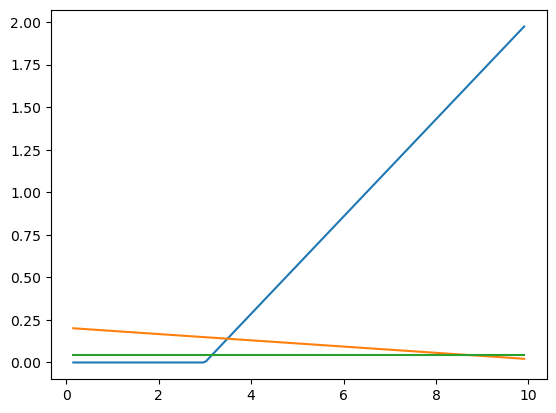

In [12]:
# Information added by Denise

impurity_unc = 0.01*ones(shape(Einc)[0],dtype = float) # per templates

background_unc = 0 # per authors.

deadtime_unc = 0 # per authors. 

# --------------------------------------------------------------------
angdistr_forwardboost_unc = zeros(shape(Einc)[0],dtype = float)  # per authors.
for index in arange(0,shape(Einc)[0]):
    if Einc[index] >= 3.0:
       angdistr_forwardboost_unc[index] =  2.0*(Einc[index]-3.0)/(10.0-3.0)
# --------------------------------------------------------------------

# --------------------------------------------------------------------
attenuation_multscatt_unc = zeros(shape(Einc)[0],dtype = float)

for index in arange(0,shape(Einc)[0]):
   attenuation_multscatt_unc[index] =  0.2 - (0.18)*(Einc[index]-0.2)/(10.0-0.2)
# --------------------------------------------------------------------

# -------------------------------------------------------------------
Ersl = 0.042*ones(shape(Einc)[0],dtype = float)  # per https://doi.org/10.1140/epja/s10050-025-01727-x .
# This is FHWM energy resolution in energy percent.
for index in arange(0,shape(Einc)[0]):
    if Ersl[index] >= 0.1 and Einc[index] <= 1.0:
        Ersl[index] =  0.042+0.016*(Einc[index]-0.1)/(1.0-0.1)
    elif Ersl[index] > 1:
        Ersl[index] = 0.058
        
#plt.xlim([1.0,10.0])
plt.plot(Einc,angdistr_forwardboost_unc)
plt.plot(Einc,attenuation_multscatt_unc)
plt.plot(Einc,Ersl)

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Constant:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-github/Data/ReferenceData_dict.txt
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
Testing cov_eunc covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing ratio covariance matri

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


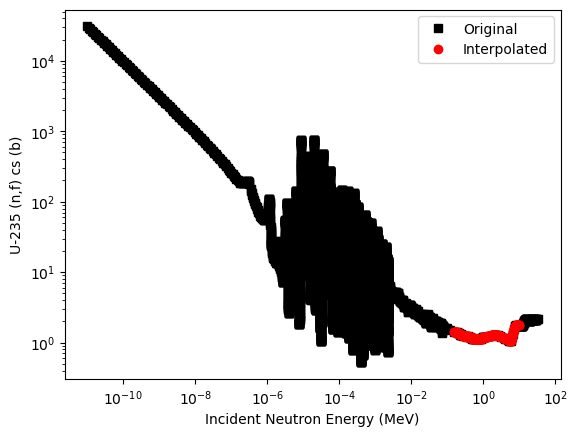

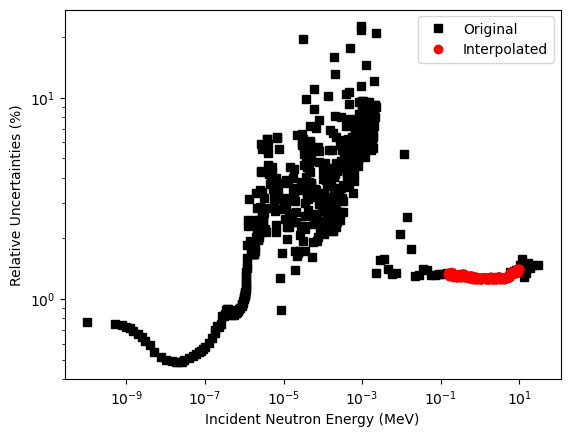

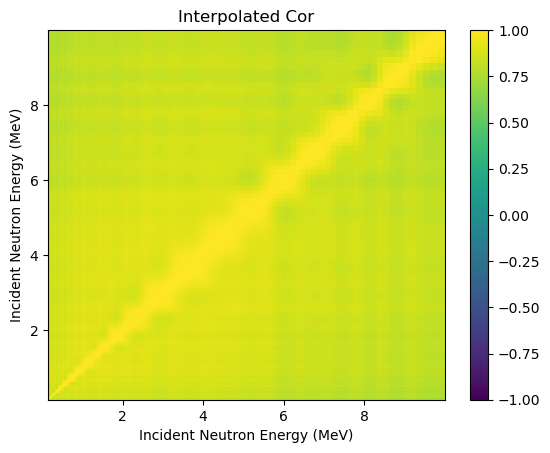

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS6006_nTOF/DS6006.xml
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS6006_nTOF/DS6006EUCLID.json
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS6006_nTOF/DS6006ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


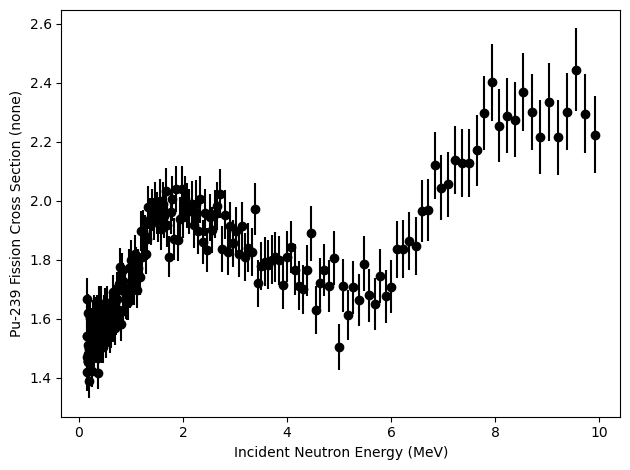

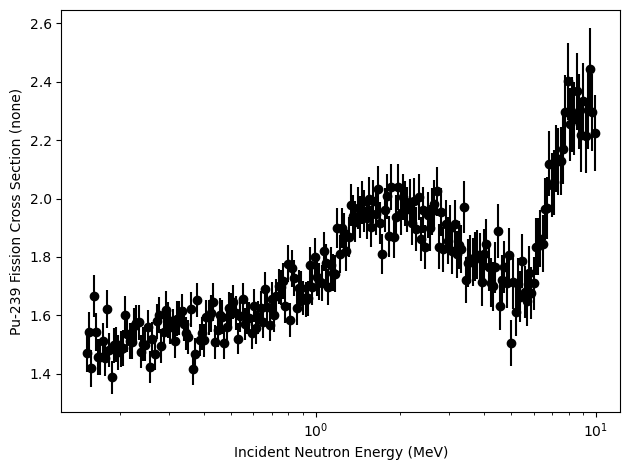

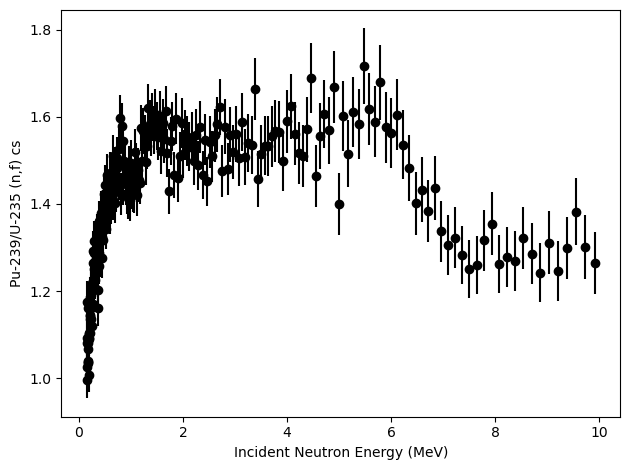

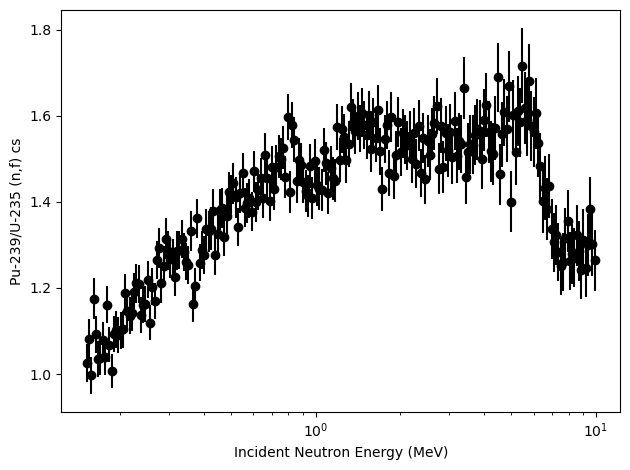

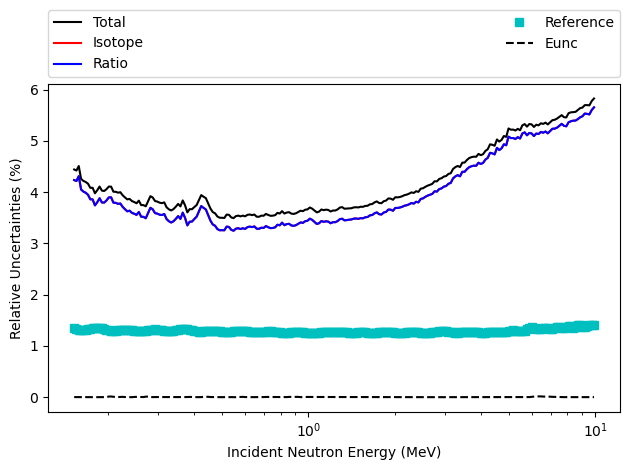

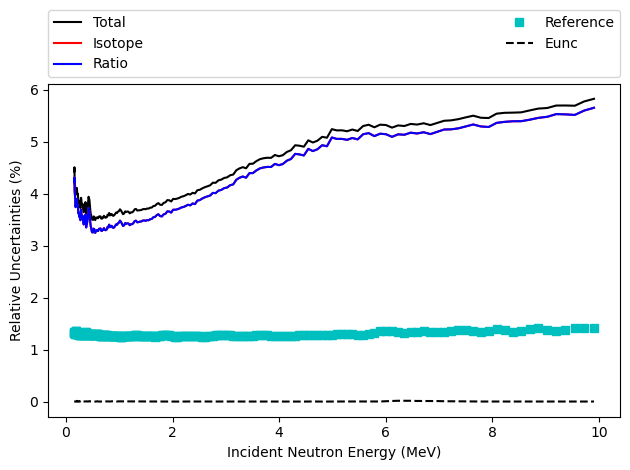

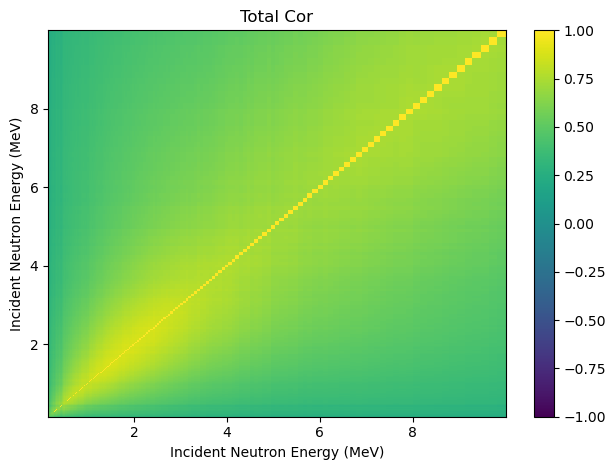

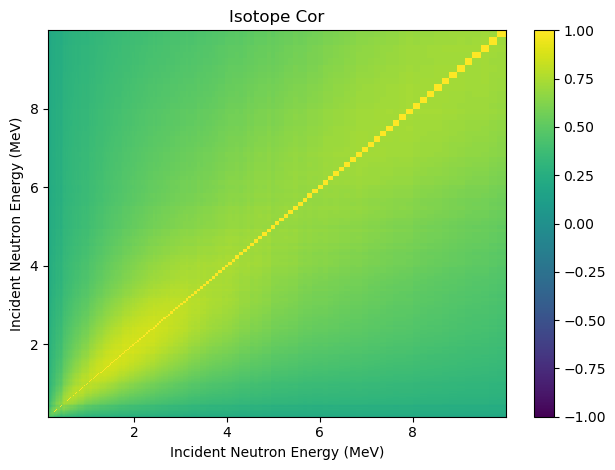

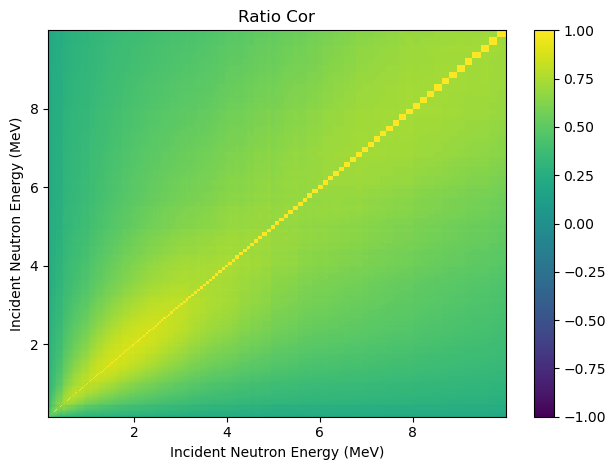

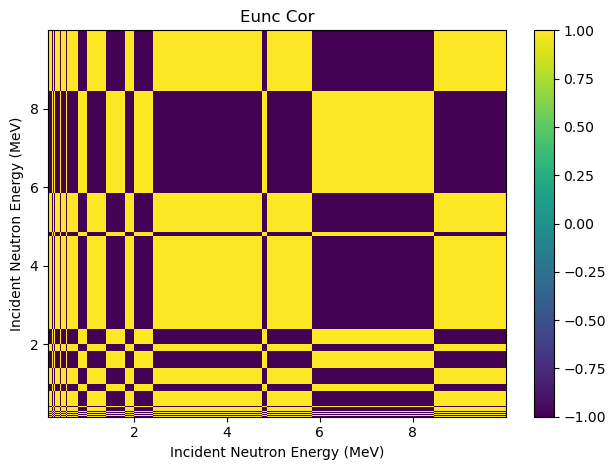

In [13]:
Documentation = """EXFOR No. = wip; the data are not yet in GMA, following the current numbering \
	and convention, I would assign D6006; Journal article = A. Sanchez-Caballero, D. Cano-Ott, \
    E. Mendoza, et al. (2025). The data used in here are all provided in private communication by N. Otsuka. \
 	on behalf of the n_TOF collaboration for the Neutron Data Standards and will be soon in EXFOR.
  - Given their write-up, I treat the data as shape ratios. At the Standards meeting in January 2026, we decided to take only the data above 150 keV and treat them as ratios to 235U because the flux was measured in the energy range as ratios to 235U(n,f) cross sections and assuming the 2018 Standard for the 235U(n,f) cross sections.
- I assume the detector efficiency uncertainty of 0.5% drops out because it is a normalization uncertainty that would have been taken care of by the normalization, but as we take the data as shape, it does not apply.
- The angular distribution and forward-boost uncertainty is energy-dependent and as such does apply to shape data. Given their answer, I add in an angular distribution and forward-boost uncertainty that is 0% up to 3 MeV and then linearly rises to 2% up to 10 MeV. I assume that the effect of sample thickness is negligible given their write-up and add no uncertainty.
- No extra uncertainty is added on the neutron flux because it is their systematic uncertainty. The neutron flux uncertainty includes the Standard uncertainty. So, I need to reduce it for that.
- I assume background uncertainties for now to be 0% per the guidance of n_TOF authors. However, note that we are just investigating with fissionTPC folks the likelihood of thermal background. Could a similar thermal background apply to them? Or is that highly unlikely because they have a much longer flight path >100 m versus 100 cm for fissionTPC? Roberto Capote wrote that they use the calorimeter and shield their detector with cadmium or boron, not recall which one, so no thermal background.
- I assume they don’t have a wrap-around background? (lowest-energy neutrons from the preceding pulse are overlapping with the fastest neutrons from the current pulse.) Roberto Capote confirmed that they have no wrap-around background.
- They only address in their answer neutron attenuation and multiple scattering in the sample but not in the surrounding. This is especially relevant as this is not a clean-ratio measurement, where U-235 is in the same chamber, but rather in different detectors where they might see a beam more distorted by neutron scattering. The key question is how far away are the neutron monitor measurements? Is there a lot of material? Right now, I would add my typical template values of 0.2-2%.
- I believe them on deadtime uncertainty being 0.
- I add a negligibly small impurity uncertainty of 0.01% (this corresponds to their sample purity of 99.9%). This is not fully correlated as the different isotopes have energy-dependent cross sections and corrections.
- Per authors, the energy resolution is 0.042% at 100 keV to 0.058% around 1 MeV. I would assume that they have a fine energy resolution until 100 keV and then getting increasingly worse above. So, I leave 0.042% until 100 keV, increase linearly to 0.058% at 1 MeV and then keep it at 0.058% above 1 MeV. """ 
   

general_info = {'name': 'DS6006', 'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6006.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', \
                           'unc': TOFlength_unc,'unc_unit': 'm'}, \
            'identifier_iso_deriv1' : 'ENDF/B-VII.1'}

# 'en_err' : {'enerr_unc': array(Eunc),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\

resolution = {'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'tof_length':TOFlength,
              'tof_length_unit':'m',
              'energy_resolution': Ersl*Einc/100.0, # it is given as FWHM in % to energy
              'energy_resolution_unit': 'MeV'}

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', 'unc': TOFlength_unc, 'unc_unit': 'm'},\
            'en_err' : {'enerr_unc': array(Ersl*0.1/2.355),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.1','resolution':resolution}

if forStandards:
    reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VIII.0'}

unc_iso = {'einc_unc': einc_unc, \
           'values':array([Statunc,angdistr_forwardboost_unc,\
                           attenuation_multscatt_unc,impurity_unc,neutronflux_unc]).transpose(),\
           'units':['%','%','%','%','%'],\
           'type':['Diagonal','Gaussian',\
                   'Gaussian','Constant','Gaussian'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,0.35,1.0]}}

if forStandards:
    data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(ratio), 'values_unit': "none" }
    DS6006_nfcs = Cnf.nfcs_cleanratioshape(general_info,data,unc_iso,reference,features)
else:
    data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "none" }
    DS6006_nfcs = Cnf.nfcs_shape(general_info,data,unc_iso,features)

Text(0, 0.5, 'Pu9(n,f) Cross Section (b)')

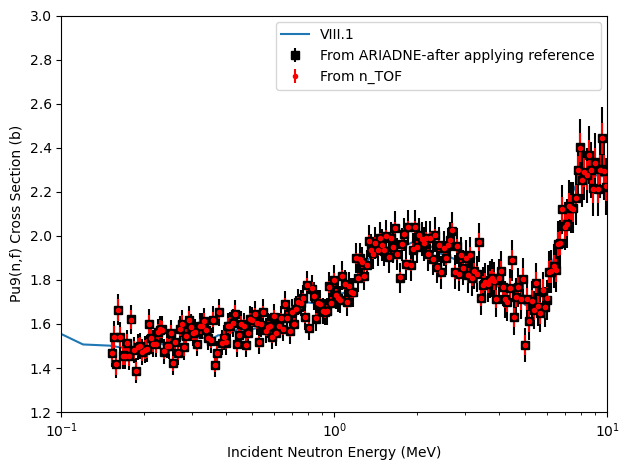

In [14]:
datafile = homedir+"Partial_Unc.dat"
alldata  = loadtxt(datafile,comments="#")
Eall     = alldata[:,0]
csall    = alldata[:,1]
csuncall = alldata[:,3]

E81 = loadtxt(homedir+'Pu239nfcsVIII1.dat.txt',comments='#')[:,0]
cs81 = loadtxt(homedir+'Pu239nfcsVIII1.dat.txt',comments='#')[:,1]

plt.xlim([0.1,10.0])
plt.ylim([1.2,3.0])
plt.semilogx(E81,cs81)
plt.errorbar(Eall,csall,csuncall*csall/100.0,color='k',fmt='s')
plt.errorbar(Eall,Data,Statunc*Data/100.0,color='r',fmt='.')
plt.xscale('log')
plt.legend(['VIII.1','From ARIADNE-after applying reference','From n_TOF'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Pu9(n,f) Cross Section (b)')

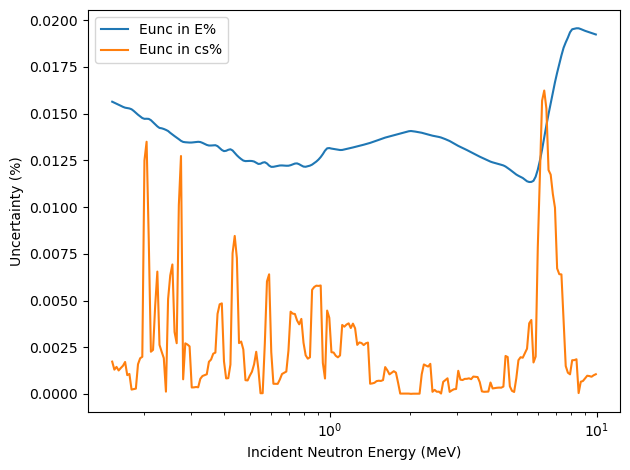

In [15]:
# get energy uncertainties in energy - this checks if they are substantial enough to include.
# the deriv_nucdata are explicitly taken from ARIADNE output.
cscov = DS6006_nfcs.cov_eunc
dim = shape(Einc)[0]
Euncov = zeros([dim,dim],dtype=float)
deriv_nucdata = [ 1.06457559e+00,8.28635493e-01,8.34936799e-01,8.38364971e-01
,8.45332907e-01,8.52693651e-01,9.53621137e-01,5.73481976e-01
,5.75071357e-01,1.38808037e-01,1.39083889e-01,1.40919929e-01
,8.34866828e-01,9.93625275e-01,1.00262241e+00,6.24843000e+00
,6.63816172e+00,4.29820613e+00,1.11152300e+00,1.12833253e+00
,2.23796040e+00,3.16968294e+00,1.26809456e+00,1.07126682e+00
,8.39156165e-01,5.44574085e-02,2.18673446e+00,2.81051573e+00
,2.76665112e+00,1.39695813e+00,1.09164971e+00,4.31553520e+00
,5.44726034e+00,3.08688688e-01,1.08218020e+00,1.09004392e+00
,1.00773692e+00,1.33307959e-01,1.33054253e-01,1.33135181e-01
,1.31595593e-01,2.93201244e-01,3.47409209e-01,3.49530743e-01
,3.52409150e-01,5.61870695e-01,6.27140829e-01,6.28174115e-01
,6.55815796e-01,1.41055155e+00,1.43240381e+00,1.45368670e+00
,5.10832924e-01,2.50244380e-01,2.48119699e-01,4.55073077e-01
,2.20406811e+00,2.24954573e+00,1.96945465e+00,7.55014784e-01
,7.65438558e-01,6.07207523e-01,1.91582444e-01,1.92066423e-01
,2.53204987e-01,3.07773065e-01,3.93779764e-01,5.24244558e-01
,3.22435280e-01,9.64846858e-03,9.46239047e-03,6.04465895e-01
,1.33784357e+00,1.36463100e+00,4.99889353e-01,1.14101405e-01
,1.13840551e-01,1.13282486e-01,1.54414048e-01,2.23537814e-01
,2.24033816e-01,2.24364167e-01,4.51838675e-01,8.09605581e-01
,8.04354789e-01,7.98507335e-01,7.17731542e-01,6.79381875e-01
,6.86633083e-01,5.04389996e-01,3.32853777e-01,3.30737883e-01
,3.30146179e-01,8.61924196e-01,8.99483462e-01,8.87085342e-01
,8.44683337e-01,8.21128165e-01,2.28490202e-01,1.17216182e-01
,5.90170373e-01,5.61117415e-01,2.90816273e-01,2.81776630e-01
,2.54240557e-01,2.54983555e-01,2.58025842e-01,4.32378051e-01
,4.30624490e-01,4.28849020e-01,4.27051577e-01,4.25267009e-01
,4.23498158e-01,4.06459013e-01,2.94852689e-01,2.93298193e-01
,2.91329502e-01,2.89961005e-01,2.88576773e-01,2.83823497e-01
,5.67087348e-02,5.64246610e-02,5.99325868e-02,6.64864337e-02
,6.63031346e-02,6.59246460e-02,6.55423873e-02,1.29811658e-01
,1.09579076e-01,9.27672637e-02,9.23828499e-02,9.19936948e-02
,9.15997803e-02,4.84294105e-02,1.52778570e-03,1.49977185e-03
,1.49253252e-03,1.48559967e-03,1.47858667e-03,4.81749115e-04
,1.03676053e-03,1.03983610e-03,1.04298336e-03,1.04620425e-03
,6.55865959e-02,1.00409792e-01,9.04109309e-02,9.07743001e-02
,9.11467314e-02,6.78000209e-03,1.18656692e-02,6.72979201e-03
,6.74494105e-03,1.27310724e-03,3.53451677e-02,4.08189475e-02
,4.11185058e-02,5.76582340e-03,9.09555467e-03,1.23687490e-02
,1.24922484e-02,5.86924072e-02,3.42673804e-02,3.45420705e-02
,3.48253140e-02,3.51174546e-02,3.54188598e-02,3.57339399e-02
,3.60750053e-02,3.64068209e-02,3.55774255e-02,2.45192987e-02
,5.34966534e-03,4.40761225e-03,4.44483417e-03,4.48323978e-03
,2.23313704e-02,1.08084694e-02,1.08653616e-02,1.09237816e-02
,1.09837813e-02,1.10452990e-02,1.37527428e-02,5.99524736e-02
,6.07516874e-02,1.27603941e-02,4.97842157e-03,3.36473529e-03
,2.15808057e-02,5.22048484e-02,5.26987383e-02,5.42505665e-02
,5.87408182e-02,6.96242474e-02,1.00404635e-01,1.01414904e-01
,4.47892940e-02,4.89335220e-02,1.86659179e-01,2.80613644e-01
,3.54050291e-01,3.47193448e-01,3.02881316e-01,2.38480753e-01
,2.21453035e-01,2.05915368e-01,1.75135547e-01,1.13190693e-01
,1.07400423e-01,1.02001939e-01,5.93566367e-02,2.25529447e-02
,1.76299683e-02,1.64407031e-02,2.58237003e-02,2.57584464e-02
,2.57353008e-02,6.85732012e-04,8.87080283e-03,8.90403308e-03
,1.10597844e-02,1.21033518e-02,1.21582407e-02,1.22145419e-02
,1.22723003e-02,1.23315621e-02]

for index1 in arange(0,dim):
    for index2 in arange(0,dim):
        Euncov[index1,index2]=cscov[index1,index2]*\
        Data[index1]*Data[index2]/\
        (Einc[index1]*Einc[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])
        

Euncrelunc = sqrt(diag(Euncov))
plt.semilogx(Einc,Euncrelunc)
plt.semilogx(Einc,sqrt(diag(cscov)))
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Uncertainty (%)')
plt.legend(['Eunc in E%','Eunc in cs%'])


In [39]:
GMAnewnumber='6006'
year = '2025'
authors = 'Sanchez-Caballero (n_TOF)'
journal = 'J,PLB,872(2026)'

dim = shape(Einc)[0]

uncertainty_descriptor = ['UNCERTAINTIES','1 Energy Unc. from ARIADNE, Ersl from https://doi.org/10.1140/epja/s10050-025-01727-x ',\
                          '3 Statistical Unc.','4 Ang. distr. + forward-boost per priv. comm.',\
                          '5 mult. scatt+attenuation per templates',\
                          '6 Neutron flux unc. which is syst. unc. in PLB (priv. comm.)', \
                          'deadtime, background unc. are 0', \
                         'impurity unc. <.02% because 99.9-pure Pu9 sample']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4,:] = [0.0, 1.0,0.01]
abc_components[5,:] = [0.99,0.01,0.5]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:4] = array([Statunc,angdistr_forwardboost_unc,\
                           attenuation_multscatt_unc,neutronflux_unc]).transpose()


normalizationunc = [0,0.0,0.0,0.0,0.0,\
                    0.0,0.0,0.0,0.0,0.0]

controlnumber = [0,0,9,1,1,1,1,1,1,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':ratio, 'values_unit': "none" }
Eunc = Euncrelunc
abs_shape = 'shape'

In [41]:
import WriteGMAOutput as WGMA
returnaddress = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Ersl,uncertainties,controlnumber,normalizationunc)